In [17]:
import neat
import numpy as np
import gymnasium as gym
import visualize
import copy

ngen = 200
max_fitness_ever = float("-inf")
best_genome_ever = None
def eval_genomes(genomes, config):
    global best_genome_ever, max_fitness_ever
    
    # Proti náhodě  
    episodes = 3 
    env = gym.make("LunarLander-v3")
    
    for genome_id, genome in genomes:
        net = neat.nn.FeedForwardNetwork.create(genome, config)
        
        total_fitness = 0.0
        
        for _ in range(episodes):
            obs, info = env.reset()
            episode_reward = 0.0
            
            terminated = False
            truncated = False
            
            while not (terminated or truncated):
                output = net.activate(obs)
                action = int(np.argmax(output))
                
                obs, reward, terminated, truncated, info = env.step(action)
                episode_reward += reward
                
                # Early stopping pro padaky
                if episode_reward < -200:
                    break
                    
            total_fitness += episode_reward
            
        # Zprůměrování fitness
        genome.fitness = total_fitness / episodes
        
        # HALL OF FAME
        if genome.fitness > max_fitness_ever:
            max_fitness_ever = genome.fitness
            best_genome_ever = copy.deepcopy(genome)
            
    env.close()

In [18]:
# Path to the configuration file
config_path = "config-feedforward"

# Load NEAT configuration
config = neat.Config(
    neat.DefaultGenome,
    neat.DefaultReproduction,
    neat.DefaultSpeciesSet,
    neat.DefaultStagnation,
    config_path
)

# Create new population
population = neat.Population(config)

# Add statistics computation for evolution logging
population.add_reporter(neat.StdOutReporter(show_species_detail=True))
stats = neat.StatisticsReporter()
population.add_reporter(stats)


winner = population.run(eval_genomes, ngen)



 ****** Running generation 0 ****** 

Population's average fitness: -192.03556 stdev: 32.21741
Best fitness: -59.60405 - size: (4, 32) - species 1 - id 48
Average adjusted fitness: 0.361
Mean genetic distance 1.090, standard deviation 0.204
Population of 100 members in 1 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ====
     1    0   100    -59.604    0.361     0
Total extinctions: 0
Generation time: 1.662 sec

 ****** Running generation 1 ****** 

Population's average fitness: -166.06084 stdev: 41.31631
Best fitness: -57.50571 - size: (5, 33) - species 1 - id 118
Average adjusted fitness: 0.442
Mean genetic distance 1.217, standard deviation 0.197
Population of 100 members in 1 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ====
     1    1   100    -57.506    0.442     0
Total extinctions: 0
Generation time: 2.153 sec (1.907 average)

 ****** Running 


Absolutně nejlepší fitness za celou dobu: 254.90192663098932


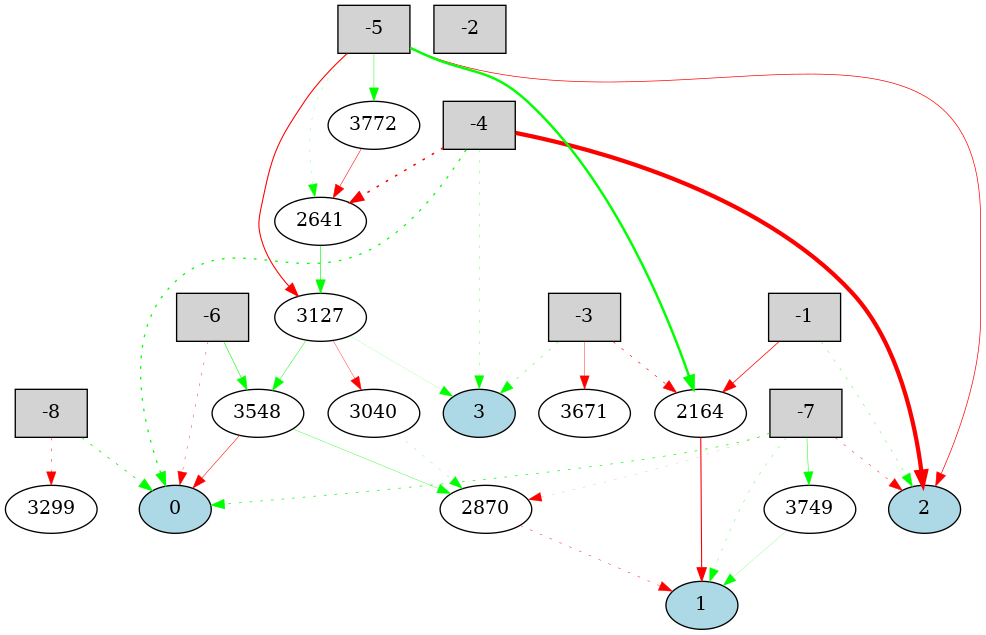

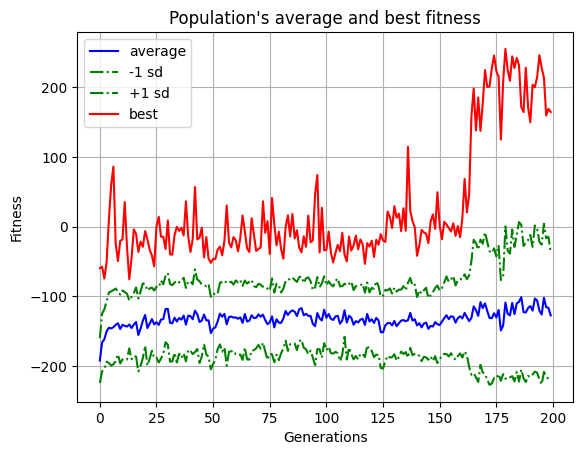

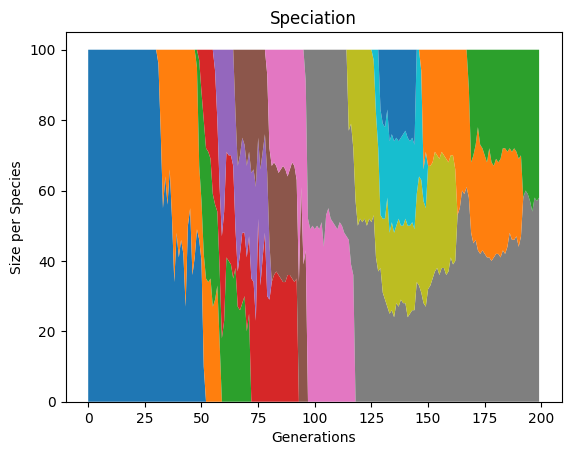

In [29]:
print(f"\nAbsolutně nejlepší fitness za celou dobu: {max_fitness_ever}")

winner_net = neat.nn.FeedForwardNetwork.create(best_genome_ever, config)

env = gym.make("LunarLander-v3", render_mode="human")
obs, info = env.reset()

terminated = False
truncated = False

while not (terminated or truncated):
    output = winner_net.activate(obs)
    action = int(np.argmax(output))
    obs, reward, terminated, truncated, info = env.step(action)

env.close()


# Render the best network
visualize.draw_net(
    config,
    genome=winner,
    show_disabled=True,
    prune_unused=False
)

# Plot the statistics
visualize.plot_stats(stats, ylog=False, view=True)
visualize.plot_species(stats, view=True)

# Lunar Lander

## Prostředí
Jako druhý problém z knihovny Gymnasium jsem vyzkoušel řešit LunarLander-v3.

## Algoritmus a jeho nastavení
Tady jsem už sáhl po NEATu (ze cvičení).

Abych to vyřešil, musel jsem fitness průměrovat přes 2 epizody (Ideálně bych to dělal třeba přes pět, ale tolik času nemáme) a dopsat si vlastní Hall of Fame (`best_genome_ever`). Také jsem musel dopsat "early stopping". Agenti totiž v prvních generacích objevili lokální optimum. Zjistili, že když jen spadnou, ztratí méně bodů, než když plýtvají palivem a snaží se létat. Jakmile tedy skóre letu kleslo pod -200, epizodu jsem ukončil, abych je donutil něco dělat..

### Hyperparametry

- ngen a počet jedinců v populaci: Velikost populace jsem srazil na 100. Na procesoru to byl ideální kompromis – netrvalo to dlouho, ale pořád to generovalo požadovanou exploraci.  Počet generací (`ngen`) jsem nastavil na 100 (v kódu je 200, abych ukázal, že ta neuronka je schopná se to actually naučit), protože proražení bariéry té "lenosti" trvalo průměrně 80 generací.
- activation_default: Nastaveno na `tanh` čistě z mé osobní preference oproti sigmoidě. 
- max_stagnation: Hodnotu jsem snížil na 15. Když se nějaký druh 15 generací nezlepšil, neviděl jsem důvod ho udržovat při životě, takže ho algoritmus rovnou vyřadil a uvolnil místo novým mutacím.
- fitness_threshold: Zvedl jsem to na 500. Většinou to fungovalo už od 150-200, ale chtěl jsem evoluci nechat běžet dokonce,  takže jsem threshold nastavil jako nedosažitelný strop.
- topologie (inputs, outputs, hidden): Počet vstupů (8) a výstupů (4) je daný prostředím. 
- node_add_prob: Nastavil jsem ho na 0.3 z 0.2, protože jsem chtěl, aby neuronka rychleji rostla. Byl to experiment, který nezhoršil výsledky, ale zároveň je moc nezlepšil. 
